# MASKING USING CENTER PICTURE AS REFERENCE 

Center Image Details:
Path: /home/projects/registration/Data/BFI_registration/212/BFI/212_Datasets_original/B_212-ST_BFI-SE_960_original.jpg
Dimensions: 3088x2076
Channels: 3


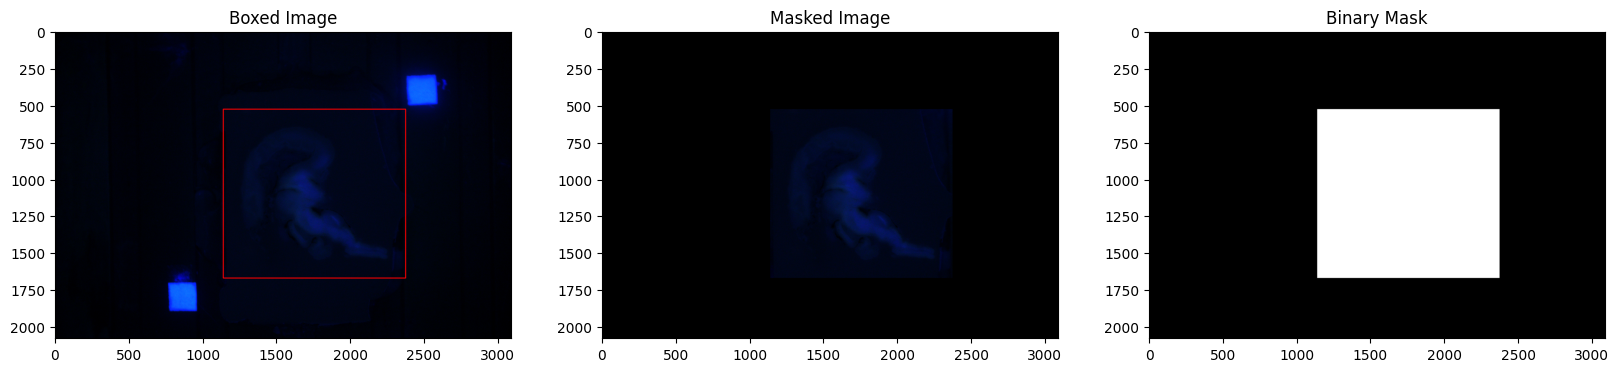

Center of Largest Bounding Box: (1756, 1099)
Center of Original Image: (1544, 1038)


In [33]:
import os
import re
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Step 1: Define input folder containing the images
input_folder = '/home/projects/registration/Data/BFI_registration/212/BFI/212_Datasets_original'

# Step 2: Function to extract the image number from the filename
def extract_image_number(filename):
    pattern = re.compile(r'_(\d+)_original\.jpg$')
    match = pattern.search(filename)
    if match:
        return int(match.group(1))
    else:
        print(f"Warning: No number found in filename {filename}. Skipping.")
        return None

# Step 3: List and sort all JPG images in the folder based on the extracted image number
image_files = [f for f in os.listdir(input_folder) if f.endswith(".jpg")]
image_files.sort(key=lambda f: extract_image_number(f) or float('inf'))

# Step 4: Identify the center image in the sorted list
center_index = len(image_files) // 2
center_image_path = os.path.join(input_folder, image_files[center_index])

# Step 5: Read the center image and get its details
center_image = cv2.imread(center_image_path)
if center_image is None:
    raise ValueError(f"Unable to read image {center_image_path}.")

height, width, channels = center_image.shape
print(f"Center Image Details:")
print(f"Path: {center_image_path}")
print(f"Dimensions: {width}x{height}")
print(f"Channels: {channels}")

# Step 6: Convert to YCrCb color space and extract the Y channel (grayscale image)
ycbcr_image = cv2.cvtColor(center_image, cv2.COLOR_BGR2YCrCb)
gray_image = ycbcr_image[:, :, 0]

# Step 7: Apply manual thresholding to create a binary mask
manual_thresh_val = 10  # Adjust this value based on the image
binary_mask = cv2.threshold(gray_image, manual_thresh_val, 255, cv2.THRESH_BINARY)[1]

# Step 8: Find contours in the binary mask
contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Step 9: Create a mask with the same dimensions as the binary image
mask = np.zeros_like(binary_mask)

# Step 10: Initialize variables to track the largest bounding box
largest_area = 0
largest_bbox = None  # To store (x, y, w, h) of the largest bounding box

# Step 11: Iterate through contours to find the largest bounding box
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    area = w * h
    if area > largest_area:
        largest_area = area
        largest_bbox = (x, y, w, h)

# Step 12: Process the largest bounding box with a buffer
buffer = 120  # Adjust this value as needed
if largest_bbox:
    x, y, w, h = largest_bbox
    x_buffered = max(0, x - buffer)
    y_buffered = max(0, y - buffer)
    w_buffered = min(center_image.shape[1] - x_buffered, w + 2 * buffer)
    h_buffered = min(center_image.shape[0] - y_buffered, h + 2 * buffer)
    
    # Fill the mask and apply to the original image
    mask[y_buffered:y_buffered + h_buffered, x_buffered:x_buffered + w_buffered] = 255
    masked_image = cv2.bitwise_and(center_image, center_image, mask=mask)
    
    # Draw the bounding box
    boxed_image = center_image.copy()
    cv2.rectangle(boxed_image, 
                  (x_buffered, y_buffered), 
                  (x_buffered + w_buffered, y_buffered + h_buffered), 
                  (0, 0, 255), 6)  # Red bounding box
    
    # Visualize the centers
    bbox_center_x = x + w // 2
    bbox_center_y = y + h // 2
    image_center_x = center_image.shape[1] // 2
    image_center_y = center_image.shape[0] // 2
    
    visualized_image = masked_image.copy()
    cv2.circle(visualized_image, (bbox_center_x, bbox_center_y), 5, (0, 255, 0), 50)  # Green dot for bounding box center
    cv2.circle(visualized_image, (image_center_x, image_center_y), 5, (255, 0, 0), 50)  # Blue dot for image center
    
    # Step 13: Display the results
    plt.figure(figsize=(20, 18))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
    plt.title("Boxed Image")
    
    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
    plt.title("Masked Image")
    
    plt.subplot(1, 3, 3)
    plt.imshow(mask, cmap='gray')
    plt.title("Binary Mask")
    plt.show()
    
    print(f"Center of Largest Bounding Box: ({bbox_center_x}, {bbox_center_y})")
    print(f"Center of Original Image: ({image_center_x}, {image_center_y})")
else:
    print("No bounding boxes found.")


In [24]:
# Step 13: Apply the mask to all sorted images and save the results



# Define the output folder path
output_folder = '/home/projects/registration/Data/BFI_registration/212/BFI/212_fiducial_removed'

# Ensure the output folder exists
os.makedirs(output_folder, exist_ok=True)

# Iterate over each image in the sorted image list
for image_file in tqdm(image_files, desc="Processing images"):
    image_path = os.path.join(input_folder, image_file)
    
    # Read the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Unable to read image {image_path}. Skipping.")
        continue

    # Apply the mask to the image
    masked_image = cv2.bitwise_and(image, image, mask=mask)
    
    # Construct the output file path
    output_image_path = os.path.join(output_folder, image_file)
    
    # Save the masked image
    cv2.imwrite(output_image_path, masked_image)
    
    #print(f"Masked image saved: {output_image_path}")

print("Masking process complete for all images.")


Processing images: 100%|████████████████████████████████████████████████████████████| 1910/1910 [04:09<00:00,  7.64it/s]

Masking process complete for all images.
